In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
data = {
    "Order_ID": [101,102,103,104,105,106,107,108,109,110],
    "Order_Time": ["12:30 PM","01:15 PM","08:00 PM","07:30 PM","02:00 PM",
                   "09:00 PM","12:45 PM","08:30 PM","01:00 PM","07:45 PM"],
    "Location": ["Chennai","Madurai","Trichy","Chennai","Coimbatore",
                 "Madurai","Chennai","Trichy","Coimbatore","Madurai"],
    "Food_Item": ["Pizza","Burger","Biryani","Pizza","Sandwich",
                  "Fried Rice","Biryani","Pizza","Burger","Noodles"],
    "Quantity": [2,1,3,1,2,1,2,1,2,1],
    "Price": [350,250,400,350,200,180,400,350,250,220]
}

df = pd.DataFrame(data)

df

,Order_ID,Order_Time,Location,Food_Item,Quantity,Price
0,101,12:30 PM,Chennai,Pizza,2,350
1,102,01:15 PM,Madurai,Burger,1,250
2,103,08:00 PM,Trichy,Biryani,3,400
3,104,07:30 PM,Chennai,Pizza,1,350
4,105,02:00 PM,Coimbatore,Sandwich,2,200
5,106,09:00 PM,Madurai,Fried Rice,1,180
6,107,12:45 PM,Chennai,Biryani,2,400
7,108,08:30 PM,Trichy,Pizza,1,350
8,109,01:00 PM,Coimbatore,Burger,2,250
9,110,07:45 PM,Madurai,Noodles,1,220


In [10]:
df["Total_Amount"] = df["Quantity"] * df["Price"]

df

,Order_ID,Order_Time,Location,Food_Item,Quantity,Price,Total_Amount
0,101,12:30 PM,Chennai,Pizza,2,350,700
1,102,01:15 PM,Madurai,Burger,1,250,250
2,103,08:00 PM,Trichy,Biryani,3,400,1200
3,104,07:30 PM,Chennai,Pizza,1,350,350
4,105,02:00 PM,Coimbatore,Sandwich,2,200,400
5,106,09:00 PM,Madurai,Fried Rice,1,180,180
6,107,12:45 PM,Chennai,Biryani,2,400,800
7,108,08:30 PM,Trichy,Pizza,1,350,350
8,109,01:00 PM,Coimbatore,Burger,2,250,500
9,110,07:45 PM,Madurai,Noodles,1,220,220


In [11]:
df.isnull().sum()

,0
Order_ID,0
Order_Time,0
Location,0
Food_Item,0
Quantity,0
Price,0
Total_Amount,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      10 non-null     int64 
 1   Order_Time    10 non-null     object
 2   Location      10 non-null     object
 3   Food_Item     10 non-null     object
 4   Quantity      10 non-null     int64 
 5   Price         10 non-null     int64 
 6   Total_Amount  10 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


In [15]:
popular_dishes = df["Food_Item"].value_counts()

popular_dishes

,count
Food_Item,
Pizza,3
Burger,2
Biryani,2
Sandwich,1
Fried Rice,1
Noodles,1


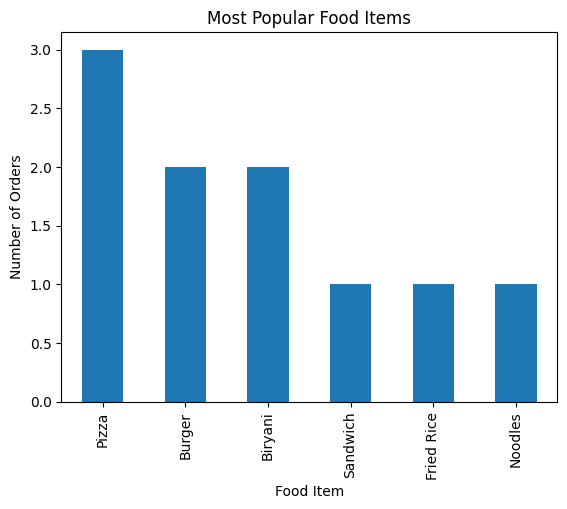

In [16]:
popular_dishes.plot(kind="bar")

plt.title("Most Popular Food Items")
plt.xlabel("Food Item")
plt.ylabel("Number of Orders")

plt.show()

In [17]:
location_orders = df["Location"].value_counts()

location_orders

,count
Location,
Chennai,3
Madurai,3
Trichy,2
Coimbatore,2


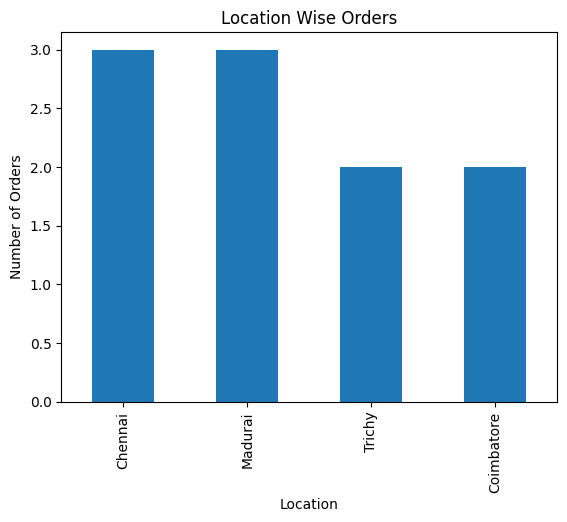

In [18]:
location_orders.plot(kind="bar")

plt.title("Location Wise Orders")
plt.xlabel("Location")
plt.ylabel("Number of Orders")

plt.show()

In [19]:
df["Hour"] = pd.to_datetime(df["Order_Time"]).dt.hour

df[["Order_Time","Hour"]]

/tmp/ipykernel_866/2413498755.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Order_Time"]).dt.hour


,Order_Time,Hour
0,12:30 PM,12
1,01:15 PM,13
2,08:00 PM,20
3,07:30 PM,19
4,02:00 PM,14
5,09:00 PM,21
6,12:45 PM,12
7,08:30 PM,20
8,01:00 PM,13
9,07:45 PM,19


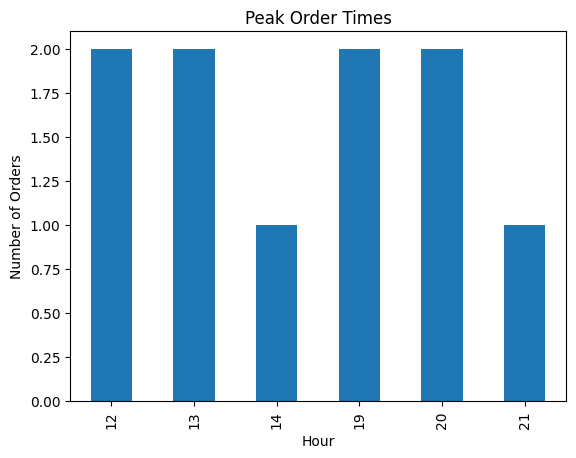

In [20]:
peak_time = df["Hour"].value_counts().sort_index()

peak_time.plot(kind="bar")

plt.title("Peak Order Times")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()

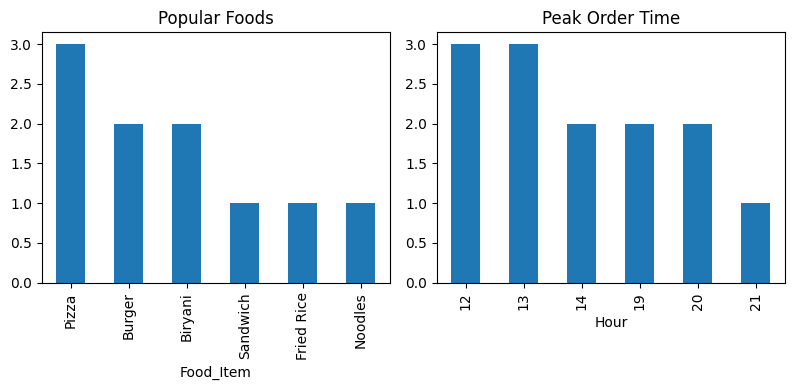

In [21]:
plt.figure(figsize=(12,4))

# Chart 1
plt.subplot(1,3,1)
df["Food_Item"].value_counts().plot(kind="bar")
plt.title("Popular Foods")

# Chart 2
plt.subplot(1,3,2)
df["Location"].value_counts().plot(kind="bar")
plt.title("Orders by Location")

# Chart 3
peak_time = df["Hour"].value_counts().sort_index()
peak_time.plot(kind="bar")
plt.title("Peak Order Time")

plt.tight_layout()
plt.show()

In [22]:
location_orders = df["Location"].value_counts()

print(location_orders)

Location
Chennai       3
Madurai       3
Trichy        2
Coimbatore    2
Name: count, dtype: int64


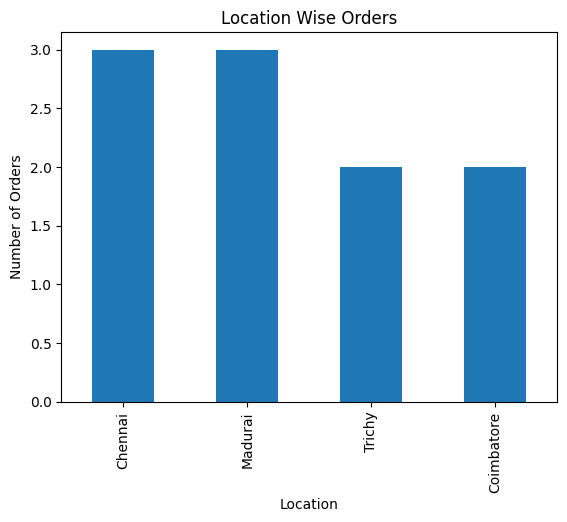

In [23]:
location_orders.plot(kind="bar")

plt.title("Location Wise Orders")
plt.xlabel("Location")
plt.ylabel("Number of Orders")

plt.show()

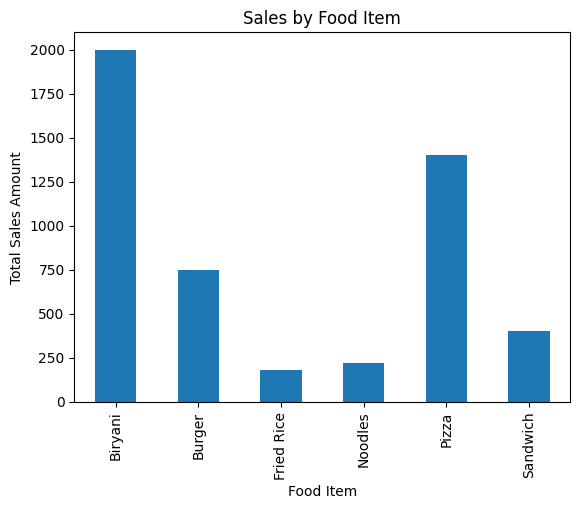

In [24]:
sales_by_item = df.groupby("Food_Item")["Total_Amount"].sum()

sales_by_item.plot(kind="bar")

plt.title("Sales by Food Item")
plt.xlabel("Food Item")
plt.ylabel("Total Sales Amount")

plt.show()

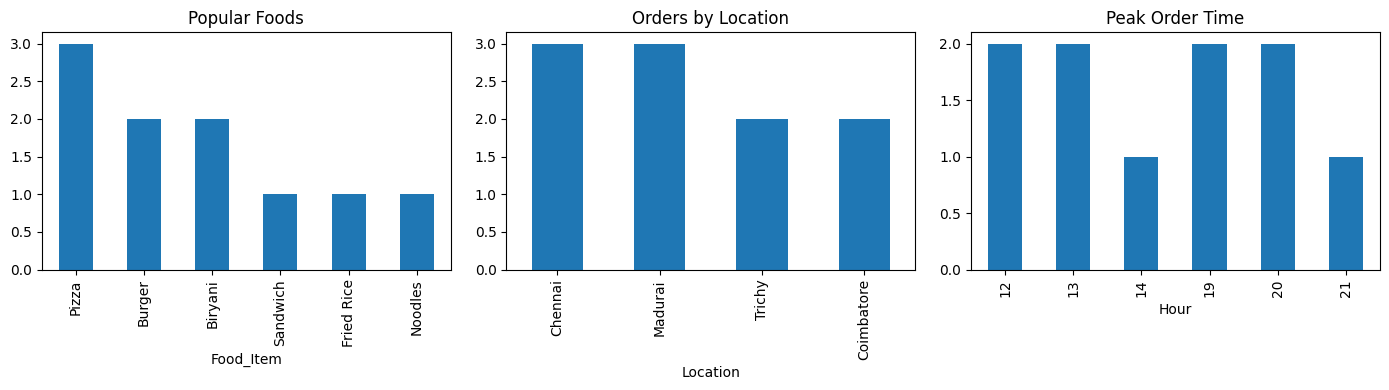

In [25]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
df["Food_Item"].value_counts().plot(kind="bar")
plt.title("Popular Foods")

plt.subplot(1,3,2)
df["Location"].value_counts().plot(kind="bar")
plt.title("Orders by Location")

plt.subplot(1,3,3)
df["Hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Peak Order Time")

plt.tight_layout()
plt.show()